### Homework 5

In [87]:
# Load packages 
#%pip install us
import us
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import numpy as np
import pyfixest as pf

In [88]:
# Load Data from HCRIS
data_2009 = pd.read_csv('../Homework4/data/output/data-2009.csv')
data_2010 = pd.read_csv('../Homework4/data/output/data-2010.csv')
data_2011 = pd.read_csv('../Homework4/data/output/data-2011.csv')
data_2012 = pd.read_csv('../Homework4/data/output/data-2012.csv')
data_2013 = pd.read_csv('../Homework4/data/output/data-2013.csv')
data_2014 = pd.read_csv('../Homework4/data/output/data-2014.csv')
data_2015 = pd.read_csv('../Homework4/data/output/data-2015.csv')
data_2016 = pd.read_csv('../Homework4/data/output/data-2016.csv')
data_2017 = pd.read_csv('../Homework4/data/output/data-2017.csv')
data_2018 = pd.read_csv('../Homework4/data/output/data-2018.csv')

In [89]:
data_2010["tot_uncomp_care_charges"] = data_2010["uncomp_care"]
data = pd.concat([data_2010, data_2011, data_2012, data_2013, data_2014, data_2015, data_2016, data_2017, data_2018], ignore_index=True)

In [90]:
data_kff = pd.read_excel('raw_data.xlsx')

In [91]:
kff_final = data_kff.copy()
kff_final["expanded"] = kff_final["Adopted: 41 states (incl. DC)  Not Adopted: 10 states"] == "Adopted"
kff_final["year"] = pd.to_datetime(kff_final["Expansion Implementation Date"], errors="coerce").dt.year.astype("Int64")
kff_final = kff_final.rename(columns={"Location": "state"})
kff_final = kff_final.rename(columns={"year": "expansion_year"})

In [92]:
data["state"] = data["state"].apply(
    lambda x: us.states.lookup(x).name if us.states.lookup(x) else x
)
data.loc[data["state"] == "DC", "state"] = "District of Columbia"
data = data[~data["state"].isin(["Puerto Rico", "Virgin Islands", "Guam", "Northern Mariana Islands"])]

In [93]:
merged = data.merge(kff_final, on="state", how="left")
merged.head()

,provider_number,fy_start,fy_end,date_processed,date_created,data_source,beds,tot_charges,net_pat_rev,tot_discounts,...,tot_uncomp_care_charges,tot_uncomp_care_partial_pmts,bad_debt,depr_HIT,year,source,Adopted: 41 states (incl. DC) Not Adopted: 10 states,Expansion Implementation Date,expanded,expansion_year
0,10001,2009-10-01,2010-09-30,2011-08-09,2011-08-05,v1996,408.0,1.116894e+09,250212573.0,866681575.0,...,90806676.0,NaN,NaN,NaN,2010,unique reports,Not Adopted,NaN,False,<NA>
1,10005,2009-10-01,2010-09-30,2011-03-09,2011-03-07,v1996,114.0,2.110556e+08,67006321.0,144049273.0,...,25141783.0,NaN,NaN,NaN,2010,unique reports,Not Adopted,NaN,False,<NA>
2,10006,2009-07-01,2010-06-30,2010-12-14,2010-12-13,v1996,358.0,6.320590e+08,129883282.0,502175755.0,...,97595621.0,NaN,NaN,NaN,2010,unique reports,Not Adopted,NaN,False,<NA>
3,10007,2009-10-01,2010-09-30,2011-02-28,2011-02-28,v1996,78.0,4.452468e+07,14349804.0,30174875.0,...,3959905.0,NaN,NaN,NaN,2010,unique reports,Not Adopted,NaN,False,<NA>
4,10008,2010-01-01,2010-12-31,2011-06-15,2011-06-14,v1996,29.0,2.750480e+07,13044287.0,14460509.0,...,3037069.0,NaN,NaN,NaN,2010,unique reports,Not Adopted,NaN,False,<NA>


# Question 1

In [94]:
merged["uncomp_care"] = (
    merged["tot_uncomp_care_charges"]
    - merged["tot_uncomp_care_partial_pmts"]
    + merged["bad_debt"]
)

merged.loc[
    merged[[
        "tot_uncomp_care_charges",
        "tot_uncomp_care_partial_pmts",
        "bad_debt"
    ]].isna().any(axis=1),
    "uncomp_care"
] = np.nan

In [95]:
merged["tot_uncomp_mills"] = merged["uncomp_care"]/1000000
question_1 = (
    merged.groupby("year", as_index=False)["tot_uncomp_mills"]
    .mean()
)
question_1 = question_1.round({"tot_uncomp_mills": 2}).rename(
    columns={
        "year": "Year",
        "tot_uncomp_mills": "Mean Uncompensated Care in Millions ($)"
    }
)
question_1

,Year,Mean Uncompensated Care in Millions ($)
0,2010,NaN
1,2011,34.66
2,2012,37.54
3,2013,39.43
4,2014,36.63
5,2015,33.37
6,2016,45.24
7,2017,41.14
8,2018,39.10


The amount of uncompensated care increased at a steady rate from 2011-2013 and then decreased in 2014 and 2015 following the ACA expansion. Then, uncompensated care increased dramatically in 2016 and decreased slightly afterwards.

## Question 2

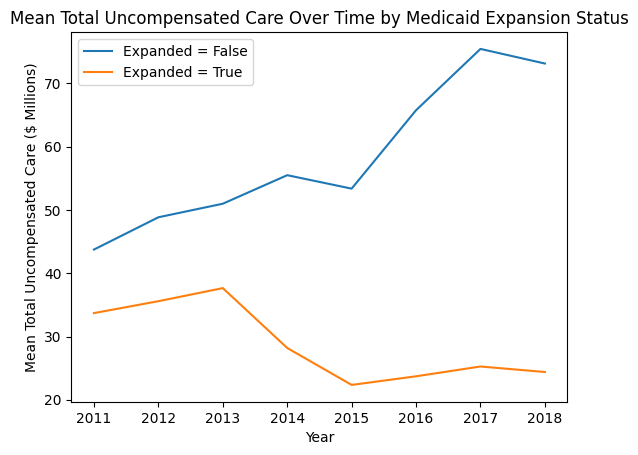

In [96]:
question_2 = merged[(merged["expansion_year"] == 2014) | (merged["expansion_year"].isna())].copy()
plot_2 = (
    question_2.groupby(["year", "expanded"], as_index=False)["tot_uncomp_mills"]
      .mean()
)

#plot_2["total_uncompensated_millions"] = plot_2["uncomp_care"] / 1000000

for status, group in plot_2.groupby("expanded"):
    plt.plot(group["year"], group["tot_uncomp_mills"], label=f"Expanded = {status}")

plt.xlabel("Year")
plt.ylabel("Mean Total Uncompensated Care ($ Millions)")
plt.title("Mean Total Uncompensated Care Over Time by Medicaid Expansion Status")
plt.legend()
plt.show()

The data suggests a possible treatment effect. It appears that uncompensated care increased in states that did not expand Medicaid and decreased in states that did expand after 2014.

## Question 3

In [97]:
question_3 = question_2[(question_2["year"] == 2012) | (question_2["year"] == 2015)].copy()
question_3["post"] = question_3["year"] >= 2015

In [98]:
dd_means = (
    question_3
    .groupby(["expanded", "post"], as_index=False)
    .agg(mean_uncomp_care=("uncomp_care", lambda x: x.mean() / 1_000_000))
)

dd_means["expanded"] = dd_means["expanded"].map({True: "Expanded", False: "Not Expanded"})
dd_means["post"] = dd_means["post"].map({True: "2015 (Post)", False: "2012 (Pre)"})

table_3 = (
    dd_means
    .pivot(index="expanded", columns="post", values="mean_uncomp_care")
    .reindex(index=["Expanded", "Not Expanded"], columns=["2012 (Pre)", "2015 (Post)"])
    .round(2)
)

table_3.index.name = ""
table_3.columns.name = ""

table_3

,2012 (Pre),2015 (Post)
,,
Expanded,35.58,22.35
Not Expanded,48.85,53.38


## Question 4 

The average uncompensated care increased in the states that did not expand Medicaid and decreased in the States that did expand, on average. This makes sense as the population that received insurance as a result of the ACA Medicaid expansion would have been contributing to the uncompensated care. Now, they have insurance that pays the hospital, decreasing the uncompensated care. However, the States that did not expand had the same population still receiving uncompensated care three years later.

## Question 5

In [99]:
dd_dat_for_reg = question_2.copy()
dd_dat_for_reg["post"] = dd_dat_for_reg["year"] >= 2014

dd_dat_for_reg["expanded"] = dd_dat_for_reg["expanded"].astype(int)
dd_dat_for_reg["post"] = dd_dat_for_reg["post"].astype(int)

dd_est = smf.ols("tot_uncomp_mills ~ expanded + post + expanded:post", data=dd_dat_for_reg).fit()

results_table = pd.DataFrame({
    "Coefficient": dd_est.params,
    "Std. Error": dd_est.bse,
    "t-stat": dd_est.tvalues,
    "p-value": dd_est.pvalues
}).round(3)

results_table.index = ["Intercept", "Expansion", "Post", "Expansion × Post"]

results_table

,Coefficient,Std. Error,t-stat,p-value
Intercept,48.159,2.129,22.617,0.0
Expansion,-12.481,2.679,-4.659,0.0
Post,15.718,2.699,5.825,0.0
Expansion × Post,-26.608,3.405,-7.814,0.0


In [100]:
# question_5 = question_2[question_2["year"].isin([2012, 2015])].copy()
# question_5["expanded"] = question_5["expanded"].astype(int)
# question_5["post"] = (question_5["year"] == 2015).astype(int)
# question_5["uncomp_care_m"] = question_5["uncomp_care"] / 1_000_000

# dd_est = smf.ols(
#     "uncomp_care_m ~ expanded + post + expanded:post",
#     data=question_5
# ).fit()

In [101]:
# question_5 = question_2.dropna(
#     subset=["tot_uncomp_mills", "expanded", "year"]
# ).copy()

# question_5["expanded"] = question_5["expanded"].astype(int)
# question_5["post"] = (question_5["year"] >= 2014).astype(int)
# #question_5["uncomp_care_m"] = question_5["tot_uncomp_care_charges"] / 1_000_000

# dd_est = smf.ols(
#     "tot_uncomp_mills ~ expanded + post + expanded:post",
#     data=question_5
# ).fit()

# results_table = pd.DataFrame({
#     "Coefficient": dd_est.params,
#     "Std. Error": dd_est.bse,
#     "t-stat": dd_est.tvalues,
#     "p-value": dd_est.pvalues
# }).round(3)

# results_table.index = ["Intercept", "Expansion", "Post", "Expansion × Post"]

# results_table

## Question 6

In [102]:
question_6 = dd_dat_for_reg.dropna(
    subset=["tot_uncomp_mills", "expanded", "post", "provider_number", "year", "state"]
).copy()
m_dd = smf.ols("tot_uncomp_mills ~ post + expanded + expanded:post", data=question_6).fit()
m_twfe = smf.ols(
    "tot_uncomp_mills ~ expanded:post + C(provider_number) + C(year)",
    data=question_6
).fit(cov_type="cluster", cov_kwds={"groups": question_6["state"]})

table_6 = pd.DataFrame({
    "Coefficient": [m_twfe.params["expanded:post"]],
    "Std. Error": [m_twfe.bse["expanded:post"]],
    "t-stat": [m_twfe.tvalues["expanded:post"]],
    "p-value": [m_twfe.pvalues["expanded:post"]],
    "Num. Obs": [int(m_twfe.nobs)],
}, index=["Expansion × Post"]).round(3)

table_6

,Coefficient,Std. Error,t-stat,p-value,Num. Obs
Expansion × Post,-30.264,6.227,-4.86,0.0,14917


The difference in differences treatment effect becomes more negative when adding in hospital and year fixed effects. This means that Medicaid expansion is associated with even greater reductions in uncompensated care when controlling for differences in hospitals and shocks for common years. 

## Question 7

In [103]:
question_7 = merged[(merged["year"] == 2012) | (merged["year"] == 2015)].copy()
question_7["post"] = question_7["year"] >= 2015

In [104]:
dd_dat_for_reg_7 = question_7.copy()

# dd_dat_for_reg_7["expanded"] = dd_dat_for_reg_7["expanded"].astype(int)
dd_dat_for_reg_7["post"] = dd_dat_for_reg_7["post"].astype(int)

# dd_dat_for_reg_7["treated_by_2015"] = (
#     dd_dat_for_reg_7["expansion_year"].notna() &
#     (dd_dat_for_reg_7["expansion_year"] <= 2015)
# ).astype(int)

dd_dat_for_reg_7["treat_post_all"] = (
    (dd_dat_for_reg_7["expansion_year"].notna()) &
    (dd_dat_for_reg_7["year"] >= dd_dat_for_reg_7["expansion_year"])
).astype(int)

#dd_dat_for_reg_7["uncomp_care_m"] = dd_dat_for_reg_7["uncomp_care"] / 1_000_000

In [105]:
question_7_2 = dd_dat_for_reg_7.dropna(
    subset=["tot_uncomp_mills", "treat_post_all", "provider_number", "year", "state"]
).copy()

question_7_2["provider_number"] = question_7_2["provider_number"].astype(str)

m_twfe_7 = pf.feols(
    "tot_uncomp_mills ~ treat_post_all | provider_number + year",
    data=question_7_2,
    vcov={"CRV1": "state"}
)

print(m_twfe_7.summary())

/local/5261/econ470001/a0/conda-env/lib/python3.13/site-packages/pyfixest/estimation/model_matrix_fixest_.py:215: UserWarning: 1017 singleton fixed effect(s) detected. These observations are dropped from the model.
  warnings.warn(


###

Estimation:  OLS
Dep. var.: tot_uncomp_mills, Fixed effects: provider_number+year
Inference:  CRV1
Observations:  4224

| Coefficient    |   Estimate |   Std. Error |   t value |   Pr(>|t|) |    2.5% |   97.5% |
|:---------------|-----------:|-------------:|----------:|-----------:|--------:|--------:|
| treat_post_all |    -18.291 |        3.507 |    -5.216 |      0.000 | -25.335 | -11.247 |
---
RMSE: 20.092 R2: 0.954 R2 Within: 0.049 
None


The difference in difference treatment effect decreased (became less negative). This is likely due to states that expanded in 2015, as these would still be considered as treated but they would not see the cost savings yet (in terms of uncompensated care). 

## Question 8

In [106]:
question_8 = question_2.copy()
#question_8["uncomp_care_m"] = question_8["tot_uncomp_care_charges"] / 1_000_000

question_8["time_to_treat"] = np.where(
    question_8["expanded"].astype(bool),
    question_8["year"] - question_8["expansion_year"],
    0
)

question_8["time_to_treat"] = question_8["time_to_treat"].clip(lower=-3)

mod_event = smf.ols(
    "tot_uncomp_mills ~ C(year, Treatment(reference=2013)):expanded + C(provider_number) + C(year)",
    data=question_8
).fit()

In [107]:
question_2["expand2014"] = question_2["expansion_year"].eq(2014).fillna(False).astype(int)

In [108]:
# Clean types
question_8 = question_2.copy()
question_8["tot_uncomp_mills"] = pd.to_numeric(question_8["tot_uncomp_mills"], errors="coerce")
question_8["provider_number"] = question_8["provider_number"].astype(str)
question_8["year"] = pd.to_numeric(question_8["year"], errors="coerce")

question_8 = question_8.dropna(subset=["tot_uncomp_mills", "provider_number", "year", "state"])

mod_event = pf.feols(
    "tot_uncomp_mills ~ i(year, expand2014, ref=2013) | provider_number + year",
    data=question_8,
    vcov={"CRV1": "state"}
)

print(mod_event.summary())
mod_event.iplot()
plt.show()

/local/5261/econ470001/a0/conda-env/lib/python3.13/site-packages/pyfixest/estimation/model_matrix_fixest_.py:215: UserWarning: 361 singleton fixed effect(s) detected. These observations are dropped from the model.
  warnings.warn(


###

Estimation:  OLS
Dep. var.: tot_uncomp_mills, Fixed effects: provider_number+year
Inference:  CRV1
Observations:  14556

| Coefficient                                          |   Estimate |   Std. Error |   t value |   Pr(>|t|) |    2.5% |   97.5% |
|:-----------------------------------------------------|-----------:|-------------:|----------:|-----------:|--------:|--------:|
| C(year, contr.treatment(base=2013))[2011]:expand2014 |      7.563 |        2.493 |     3.033 |      0.004 |   2.507 |  12.620 |
| C(year, contr.treatment(base=2013))[2012]:expand2014 |      1.994 |        2.459 |     0.811 |      0.423 |  -2.994 |   6.981 |
| C(year, contr.treatment(base=2013))[2014]:expand2014 |    -12.195 |        3.104 |    -3.929 |      0.000 | -18.490 |  -5.900 |
| C(year, contr.treatment(base=2013))[2015]:expand2014 |    -17.424 |        3.875 |    -4.497 |      0.000 | -25.283 |  -9.566 |
| C(year, contr.treatment(base=2013))[2016]:expand2014 |    -30.771 |        5.830 |    -5.278

In [109]:
import pandas as pd
import matplotlib.pyplot as plt

# Get coefficient table
tidy = mod_event.tidy()

# Look at names first
print(tidy)

                                                     Estimate  Std. Error  \
Coefficient                                                                 
C(year, contr.treatment(base=2013))[2011]:expan...   7.563482    2.493418   
C(year, contr.treatment(base=2013))[2012]:expan...   1.993512    2.459061   
C(year, contr.treatment(base=2013))[2014]:expan... -12.194801    3.103796   
C(year, contr.treatment(base=2013))[2015]:expan... -17.424329    3.874800   
C(year, contr.treatment(base=2013))[2016]:expan... -30.771245    5.829998   
C(year, contr.treatment(base=2013))[2017]:expan... -42.721411    8.016992   
C(year, contr.treatment(base=2013))[2018]:expan... -46.933356    8.369506   

                                                     t value  Pr(>|t|)  \
Coefficient                                                              
C(year, contr.treatment(base=2013))[2011]:expan...  3.033379  0.004468   
C(year, contr.treatment(base=2013))[2012]:expan...  0.810680  0.422876   
C(year, co

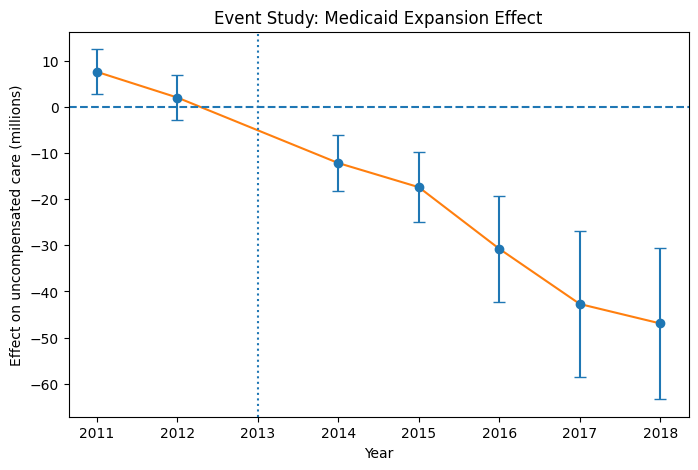

In [110]:
import matplotlib.pyplot as plt

tidy = mod_event.tidy().copy()

# move index into a normal column
tidy = tidy.reset_index()

# keep only the event-study interaction coefficients
es = tidy[tidy["Coefficient"].astype(str).str.contains(r"C\(year", na=False)].copy()

# extract year from names like:
# C(year, contr.treatment(base=2013))[2011]:expand2014
es["plot_year"] = es["Coefficient"].str.extract(r"\[(\d{4})\]").astype(int)

# sort
es = es.sort_values("plot_year")

# confidence intervals
es["ci_low"] = es["Estimate"] - 1.96 * es["Std. Error"]
es["ci_high"] = es["Estimate"] + 1.96 * es["Std. Error"]

# plot
plt.figure(figsize=(8,5))
plt.errorbar(
    es["plot_year"],
    es["Estimate"],
    yerr=1.96 * es["Std. Error"],
    fmt="o",
    capsize=4
)
plt.plot(es["plot_year"], es["Estimate"])
plt.axhline(0, linestyle="--")
plt.axvline(2013, linestyle=":")
plt.xticks([2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018])
plt.xlabel("Year")
plt.ylabel("Effect on uncompensated care (millions)")
plt.title("Event Study: Medicaid Expansion Effect")
plt.show()

In [111]:
# import pyfixest as pf
# import pandas as pd

# question_8 = question_2.copy()

# question_8 = question_8[question_8["expanded"].notna()].copy()

# question_8["tot_uncomp_mills"] = pd.to_numeric(question_8["tot_uncomp_mills"], errors="coerce")
# question_8["expanded"] = pd.to_numeric(question_8["expanded"], errors="coerce")
# question_8["provider_number"] = question_8["provider_number"].astype(str)
# question_8["year"] = question_8["year"].astype(int)

# question_8 = question_8.dropna(subset=["tot_uncomp_mills", "expanded", "provider_number", "year", "state"])

# mod_event = pf.feols(
#     "tot_uncomp_mills ~ i(year, expanded, ref=2013) | provider_number + year",
#     data=question_8,
#     vcov={"CRV1": "state"}
# )

# print(mod_event.summary())

In [112]:
# import matplotlib.pyplot as plt

# mod_event = pf.feols(
#     "tot_uncomp_mills ~ i(year, expanded, ref=2013) | provider_number + year",
#     data=question_8,
#     vcov={"CRV1": "state"}
# )

# mod_event.iplot(
#     plot_backend="matplotlib",
#     cat_template="year::{value}"
# )
# plt.show()

In [113]:
# question_8 = question_2.copy()
# #question_8["uncomp_care_m"] = question_8["tot_uncomp_care_charges"] / 1_000_000

# question_8["time_to_treat"] = np.where(
#     question_8["expanded"].astype(bool),
#     question_8["year"] - 2013,
#     0
# )

# question_8["time_to_treat"] = question_8["time_to_treat"].clip(lower=-3)

# mod_event = smf.ols(
#     "tot_uncomp_mills ~ C(time_to_treat)*expanded + C(provider_number) + C(year)",
#     data=question_8
# ).fit()

In [114]:
# # collect coefficients and CIs
# params = mod_event.params
# conf = mod_event.conf_int()
# conf.columns = ["low", "high"]

# rows = []

# for name in params.index:
#     if ":expanded" in name and "C(time_to_treat)" in name:
#         # extract event time from term name
#         # example name: C(time_to_treat)[T.-2]:expanded
#         event_time = name.split("[T.")[1].split("]")[0]
#         rows.append({
#             "event_time": float(event_time),
#             "coef": params[name],
#             "low": conf.loc[name, "low"],
#             "high": conf.loc[name, "high"]
#         })

# event_df = pd.DataFrame(rows).sort_values("event_time")

# # add omitted reference period manually as 0
# # usually the omitted category is the reference event time
# ref_period = sorted(question_8["time_to_treat"].dropna().unique())[0]  # replace if needed
# print("Check omitted reference period from model coding")

# plt.figure(figsize=(8,5))
# plt.errorbar(
#     event_df["event_time"],
#     event_df["coef"],
#     yerr=[event_df["coef"] - event_df["low"], event_df["high"] - event_df["coef"]],
#     fmt="o"
# )
# plt.axhline(0, linestyle="--")
# plt.axvline(-0.5, linestyle="--")  # separates pre and post if treatment starts at 0
# plt.xlabel("Event Time")
# plt.ylabel("Effect on Uncompensated Care (millions)")
# plt.title("Event Study Plot")
# plt.show()

In [115]:
# question_8["treated"] = np.where(
#     question_8["expansion_year"].notna() & (question_8["expansion_year"] == 2014),
#     1,
#     0
# )

## Question 9

In [116]:
# time to treat = ifelse(expand)ever == TRUE, year - expand_year, -1) 
question_9 = merged.copy()
#question_9["uncomp_care_m"] = question_9["tot_uncomp_care_charges"] / 1_000_000
question_9 = question_9.dropna(
    subset=["tot_uncomp_mills", "expanded", "provider_number", "year", "state"]
).copy()

question_9["time_to_treat"] = np.where(
    question_9["expanded"].astype(bool),
    question_9["year"] - question_9["expansion_year"],
    -1
)

question_9["time_to_treat"] = question_9["time_to_treat"].clip(lower=-3, upper=3)

mod_event_9 = smf.ols(
    "tot_uncomp_mills ~ C(time_to_treat, Treatment(reference=-1)):expanded + C(provider_number) + C(year)",
    data=question_9
).fit(cov_type="cluster", cov_kwds={"groups": question_9["state"]})

tidy_9 = mod_event_9.summary2().tables[1].reset_index()
tidy_9 = tidy_9.rename(columns={"index": "Coefficient"})

print(tidy_9[["Coefficient", "Coef.", "Std.Err."]])

                                            Coefficient       Coef.   Std.Err.
0                                             Intercept   94.722336   6.439927
1                           C(provider_number)[T.10005]  -75.265911   2.545415
2                           C(provider_number)[T.10006]  -59.197264   2.406821
3                           C(provider_number)[T.10007] -104.429777   3.521400
4                           C(provider_number)[T.10010]  -91.781539   6.439927
...                                                 ...         ...        ...
3888  C(time_to_treat, Treatment(reference=-1))[T.-2...    0.397339   1.734897
3889  C(time_to_treat, Treatment(reference=-1))[T.0....  -15.302954   5.952717
3890  C(time_to_treat, Treatment(reference=-1))[T.1....   -1.747659  17.633172
3891  C(time_to_treat, Treatment(reference=-1))[T.2....  -41.149313  14.198549
3892  C(time_to_treat, Treatment(reference=-1))[T.3....  -37.411134   7.829838

[3893 rows x 3 columns]


/home/segitli/econ470/a0/pyenv/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 3892, but rank is 13
  warnings.warn('covariance of constraints does not have full '


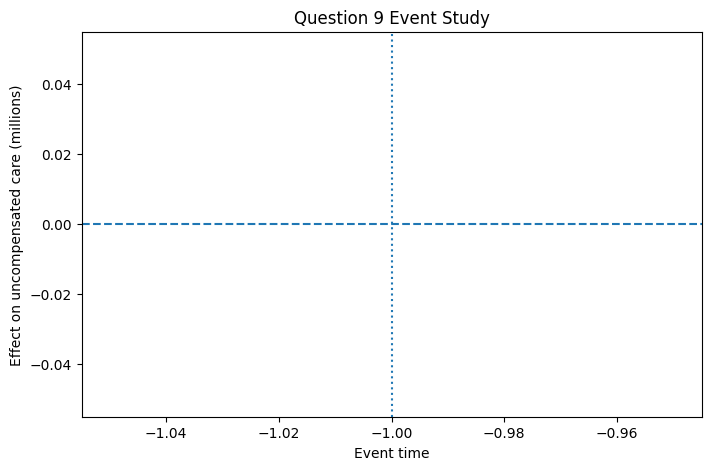

In [117]:
plot_df = tidy_9[
    tidy_9["Coefficient"].str.contains(":expanded\\[T.True\\]", regex=True, na=False)
].copy()

plot_df["event_time"] = (
    plot_df["Coefficient"]
    .str.extract(r"\[T\.(-?\d+)\.0\]:expanded\[T\.True\]", expand=False)
    .astype(int)
)
plot_df = plot_df.sort_values("event_time")

plot_df["ci_low"] = plot_df["Coef."] - 1.96 * plot_df["Std.Err."]
plot_df["ci_high"] = plot_df["Coef."] + 1.96 * plot_df["Std.Err."]

plt.figure(figsize=(8,5))
plt.errorbar(
    plot_df["event_time"],
    plot_df["Coef."],
    yerr=1.96 * plot_df["Std.Err."],
    fmt="o",
    capsize=4
)
plt.plot(plot_df["event_time"], plot_df["Coef."], marker="o")
plt.axhline(0, linestyle="--")
plt.axvline(-1, linestyle=":")
plt.xlabel("Event time")
plt.ylabel("Effect on uncompensated care (millions)")
plt.title("Question 9 Event Study")
plt.show()

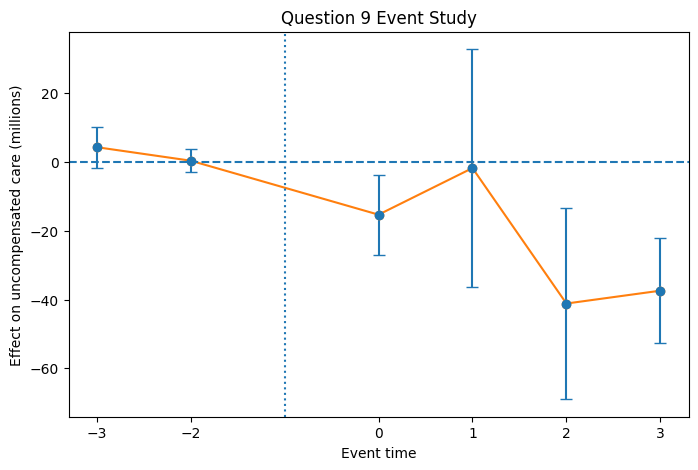

In [118]:
# keep only the interaction terms, which are the event-study effects
plot_df = tidy_9[
    tidy_9["Coefficient"].str.contains(r"expanded\[True\]", regex=True, na=False)
].copy()

plot_df["event_time"] = (
    plot_df["Coefficient"]
    .str.extract(r"\[T\.(-?\d+)\.0\]:expanded\[True\]", expand=False)
    .astype(int)
)
plot_df = plot_df.sort_values("event_time")
plot_df["ci_low"] = plot_df["Coef."] - 1.96 * plot_df["Std.Err."]
plot_df["ci_high"] = plot_df["Coef."] + 1.96 * plot_df["Std.Err."]

plt.figure(figsize=(8,5))
plt.errorbar(
    plot_df["event_time"],
    plot_df["Coef."],
    yerr=1.96 * plot_df["Std.Err."],
    fmt="o",
    capsize=4
)
plt.plot(plot_df["event_time"], plot_df["Coef."], marker="o")
plt.axhline(0, linestyle="--")
plt.axvline(-1, linestyle=":")
plt.xlabel("Event time")
plt.ylabel("Effect on uncompensated care (millions)")
plt.title("Question 9 Event Study")
plt.xticks(sorted(plot_df["event_time"].unique()))
plt.show()

## Question 10

Questions 5-9 all support the trend that expanded Medicaid decreases uncompensated care overtime when compared to states that did not expand Medicaid. Question 9 demonstrates that there the parallel trend assumption is valid. The pre-period uncompensated care effects are very close to 0, indicating the uncompensated care does not decrease before expanding Medicaid. One issue with staggered Medicaid expansion is that the states that expanded later on are still considered expanded. As demonstrated in question 7, this makes the effects differences in uncompensated care smaller because the states are considered treated even before they undergo the treatment.

Questions for class:
-For question 5 do we need to use the fixest pacakge or can we use his python code? 
-For question 6 I dropped NA values for uncomp_care; should this actually be 0?